# **Predicting Melbourne House Prices**

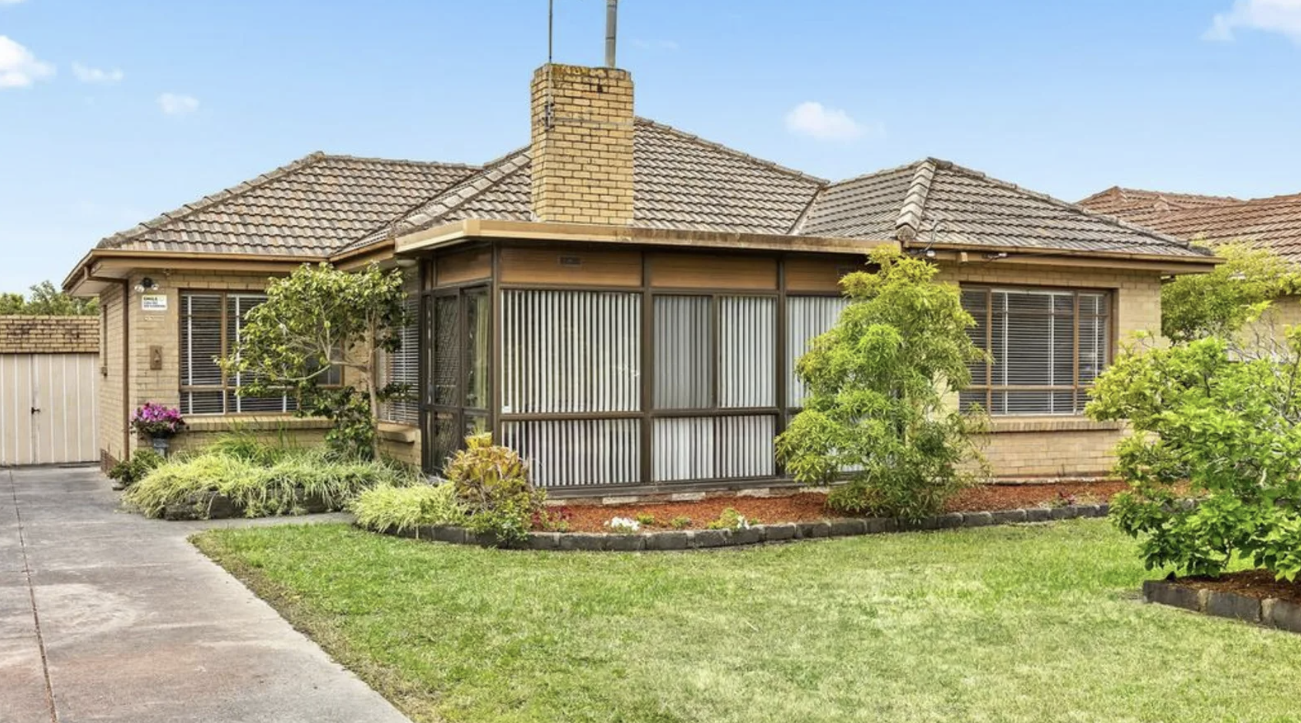

Melbourne is the largest city in Victora, Australia and continues to grow rapidly. Over the past several years Melbourne has become one of the most expensive places to buy a home in the world, cosistently sitting in the top ten according to multiple sources. This has caused even modest homes (like the one pictured above) to become highly unaffordable and difficult to obtain.

### **The Aim**

By utilising expoloratory data analysis and machine learning, this project aims to accurately predict house prices in Melbourne using this [dataset]("https://www.kaggle.com/datasets/anthonypino/melbourne-housing-market") which includes variables such as location, number of rooms and property type.

### **The Objective**

If we were working at a real estate firm, the business objective might be to use the outputs of our model(s) to determine whether or not to invest in certain areas. However, because this is a personal project we will use our findings for our own interests.

### **The System Design**

Now that we have our aim and objective, we determine the types of models to use.

**Supervised or Unsupervised Learning?**
- This is a <u>*supervised learning*</u> task, as we can train the model with labelled examples

**Classification, Regression or something else?**
- This would be a <u>*regression*</u> task as the model will predict a value (House prices)
    - Furthermore, this would be a <u>*univariate*</u>, <u>*multiple regression*</u> task as we want to predict a single value based on multiple features

**Online Learning or Batch Learning?**
- This is a <u>*batch Learning*</u> task as we don't have a continuous stream of data coming in, and the size of the data is small enough to store in memory.



### **The Performance Measure**

For this task, we will use RSME(Root Mean Squared Error) as our main performance measure as it is typically used for regression tasks.

### **The Data**

This project will be using [this dataset]("https://www.kaggle.com/datasets/anthonypino/melbourne-housing-market") which includes the following:

- Suburb
- Address
- Rooms (The number of rooms)
- Type
    - br = bedroom(s)
    - br - bedroom(s);
    - h - house,cottage,villa, semi,terrace;
    - u - unit, duplex;
    - t - townhouse;
    - dev site - development site;
    - o res - other residential.
- Price (In Australian Dollars) *this is our target variable i.e the thing we're trying to predict*
- Method
    - S - property sold;
    - SP - property sold prior;
    - PI - property passed in;
    - PN - sold prior not disclosed;
    - SN - sold not disclosed;
    - NB - no bid;
    - VB - vendor bid;
    - W - withdrawn prior to auction;
    - SA - sold after auction;
    - SS - sold after auction price not disclosed.
    - N/A - price or highest bid not available.
- SellerG (Real estate agent)
- Date (Date Sold)
- Distance (Distance to CBD in km)
- Postcode
- Regionname (General Region (West, North West, North, North east …etc))
- Propertycount (Number of properties that exist in the suburb)
- Bedroom2 (Scraped # of Bedrooms (from different source))
- Bathroom (Number of Bathrooms)
- Car (Number of carspots)
- Landsize (Land Size in Metres)
- BuildingArea (Building Size in Metres)
- YearBuilt (Year the house was built)
- CouncilArea (Governing council for the area)
- Latitude
- Longitude

### **Importing Libraries**

We'll import the libraries here 

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import datetime
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV


Load the data:

In [ ]:
housing = pd.read_csv("C:/Users/jungn/OneDrive/Documents/Projects/Melbourne-Housing-Price-Prediction/data/Melbourne_housing_FULL.csv")

### **Exploratory Data Analysis**

We want to know about the data itself:
- Does it have missing values? (if so which variables?)
- Does it have duplicate rows?
- Does it contain categorical variables?
- What is the shape of the data (How many rows and columns?)

We also want to get an idea of the relationships and the overall "behaviour" of the data

Taking a quick peek:

In [ ]:
housing.head()

In [ ]:
housing.info()

In [ ]:
housing.shape

Seems like there's a total of eight categorical variables, such as CouncilArea, SellerG and Suburb. We will deal with these later.

We also see that there are 21 variables, 14 of which have at one or more missing values(Non-Null counts lower than 34857). We will have to deal with these as well.

In [ ]:
housing.duplicated().sum()

We have one duplicate row

In [ ]:
housing[housing.duplicated(keep=False)]

Found it :)

In [ ]:
housing.describe().T

We see some interesting things, for example the min value of "YearBuilt" is 1196 and the max is 2106 which doesn't make sense at all. These anomalies will be considered as missing data.

We also see that the min value for some variables are 0. This would make sense for variables like "Car" and  "Distance", however it would not make sense for variables such as "LandSize", "BuildingArea", "Bathroom" and "Bedroom". These variables will be considered as missing values if they have 0. 

In [ ]:
cat_cols = ['Suburb', 'Address', 'Type', 'Method', 
            'SellerG', 'Date', 'CouncilArea', 'Regionname']
num_cols = [col for col in housing.columns if col not in cat_cols]

In [ ]:
housing.hist(["Rooms","Price","Distance","Bedroom2","Bathroom","Car","Landsize","BuildingArea","YearBuilt", "Lattitude", "Longtitude", "Propertycount"],bins = 50, figsize=(20,15))
plt.show()

Cool histograms that show which variables might need feature scaling.

### **Cleaning, Fixing, Engineering**

Starting off with the date column, this is a column that is very "feature engineerable". We will add three new columns.

We can separate the date into years, months and days, and see how many houses were sold in each particular category

In [ ]:
housing["Date"] = pd.to_datetime(housing["Date"], format = "%d/%m/%Y") #change the format to day-month-year
print(housing['Date'].dtype)

In [ ]:
housing['Month_Sold'] = housing['Date'].dt.month
housing['Year_Sold'] = housing['Date'].dt.year
housing['Day_Sold'] = housing['Date'].dt.day_name()
housing['Date'] = housing['Date'].astype(str)

cat_cols.append('Day_Sold')

We'll also create a new "BuildingAge" column:

In [ ]:
housing['BuildingAge'] = datetime.date.today().year - housing['YearBuilt']
num_cols.append('BuildingAge')

In [ ]:
housing.head()

In [ ]:
housing["Year_Sold"].value_counts()

In [ ]:
housing["Month_Sold"].value_counts().sort_index(ascending=True)

In [ ]:
housing["Day_Sold"].value_counts()

It seems like most houses were sold on weekends, with none being sold on Wednesday and Friday.

### **Let's get rid of that duplicate row**

The "low hanging fruit" so to speak

In [ ]:
housing.drop_duplicates(inplace=True, keep="first")

### **Missing Values**

Here comes the "high hanging fruit" 

There are different methods one can use to deal with missing values. One obvious choice would be to simply drop them, however this can be quite destructive especially when there are a lot of missing entries. 

Since this is the case for a lot of our variables we can turn to imputation, which involves estimating the missing values based on non missing data.

In [ ]:
#missing data
pd.concat([housing.isnull().sum(), housing.isnull().sum()/len(housing) * 100], keys = ["Number of missing values", "Percentage of missing values"], axis = 1)

Some things we noticed was that some variables had "0" as their minimum value, which didn't make sense, such as Bedroom, Bathroom, Landsize, BuildingSize and Bedroom2.

In [ ]:
#We want to change these values to N/A

minval_0_to_na = ['Bathroom', 'Landsize', 'BuildingArea'] 

for i in minval_0_to_na:
    housing[i].replace({0:np.nan}, inplace = True)

housing[['Bathroom', 'Landsize', 'BuildingArea']].eq(0).sum()

we also change the "YearBuilt" variable as some houses were built after it was sold and some were built before 1850

In [ ]:
housing.loc[(housing['YearBuilt'] > housing['Year_Sold']) | (housing['YearBuilt'] < 1850), 'YearBuilt'] = np.nan

#### Another interesting thing was the fact that "Postcode" and "Distance" only had one missing value.

In [ ]:
housing[housing["Postcode"].isnull()]

It appears that both the missing "Postcode" and "Distance" are in the same row. Thankfully, since the postcode and distance is only missing in one row, we can simply search these facts up and fix it up and while we're at it we'll also fill in CouncilArea, Regionname and Propertycount.

A quick Google search gives us the postcode; 3060, and the distance from the CBD; around 12km.

In [ ]:
housing.loc[housing["Suburb"]=="Fawkner"].T

It appears that the correct suburb name is "Fawkner" and not "Fawkner Lot"

In [ ]:
'Fawkner' in housing['Suburb'].unique()

In [ ]:
housing.loc[(housing["Suburb"] == 'Fawkner') & (housing["Address"] == '3 Brian St')]

We see two instances of 3 Brian St, with their difference being their sell date.

We fill in the missing values using another row:

In [ ]:
for col, val in zip(housing.iloc[11247,:].index, housing.iloc[11247,:].values):
    if col in ['Date', 'Month', 'Year']:
        pass
    else:
        housing.loc[housing.index==29483, col] = val

In [ ]:
housing[housing["Postcode"].isnull()]
housing[housing["Distance"].isnull()]

### RegionArea, CouncilArea, Propertycount had missing values in three rows

One row was the "Fawkner" suburb which has been taken care of, so now there's two rows to handle. Which means the other two rows are:

In [ ]:
pd.concat([housing[housing['Regionname'].isnull()],
           housing[housing['CouncilArea'].isnull()],
           housing[housing['Propertycount'].isnull()]]).drop_duplicates()

In [ ]:
footscray_sub_filter = (housing["Suburb"] == 'Footscray') & (housing["Address"] == '2/16 Stafford St')
camberwell_sub_filter = (housing["Suburb"] == 'Camberwell') & (housing["Address"] == '2/3 Kingsley St')

footscray_filter = housing["Suburb"] == 'Footscray'
camberwell_filter = housing["Suburb"] == 'Camberwell'

In [ ]:
missing_cols = ['Regionname', 'CouncilArea', 'Propertycount']

for col in missing_cols:
    footscray_value = housing.loc[footscray_filter, col].unique()[0]
    camberwell_value = housing.loc[camberwell_filter, col].unique()[0]

    housing.loc[footscray_sub_filter, col] = footscray_value
    housing.loc[camberwell_sub_filter, col] = camberwell_value

### **Imputing missing values**

For the rest of the missing values we will use sklearn's KNN imputer, a more powerful alternative to simply replacing the missing values with the mean or median.

This imputer replaces each missing value with the mean of the k-nearest neighbours' value for that feature based on all available features

In [ ]:
imputer = KNNImputer(n_neighbors=5)
housing[num_cols] = imputer.fit_transform(housing[num_cols])

### **Handling categorical variables**

Since there's no efficient way to encode "Address" we just get rid of it, and encode the other categorical variables.

In [ ]:
for col in cat_cols:
    le = LabelEncoder()
    housing[col] = le.fit_transform(housing[col])

### **Feature Scaling**

Looking back at the histogram made earlier, the Price variable is quite heavy-tailed, in other words most of the values are squashed to one side.

In [ ]:
# we do a log transformation first, to prevent the few very large numbers from dominating

housing["LogPrice"] = np.log1p(housing["Price"])

scaler = StandardScaler()

housing["LogPriceScaled"] = scaler.fit_transform(
    housing[["LogPrice"]]
).ravel()

In [ ]:
housing.hist(["LogPrice"],bins = 50, figsize=(15,10))
plt.show()

That looks much more symmetrical

### **Dealing with collinearity**

Collinearity is a situation when two or more predictors are highly correlated with each other. This becomes an issue as we won't know the individual effects of the collinear variables on the response/target variable.

To see things clearly, we'll make a correlation heat map:

In [ ]:
corr_matrix = housing.corr(numeric_only=True)

sns.heatmap(corr_matrix)
plt.show()

It's very clear that Bedroom2 and Rooms are highly correlated

In [ ]:
corr_matrix

Looking closely, we see that Bedroom2 and Rooms have a coefficient of 0.92, which is extremely high. In this situation we will drop Bedroom2, as not only does it contain more missing values, it seems like it's also quite correlated with "Bathroom", with a coefficient of around 0.63.

In [ ]:
housing.drop(["Bedroom2"], inplace=True, axis=1)
num_cols.remove('Bedroom2')

### **Visualising the Data**

Let's have a look at the geographical data

In [ ]:
housing.plot(kind="scatter", x="Lattitude", y="Longtitude", grid=True)
plt.show()

It's something, lets try something else.

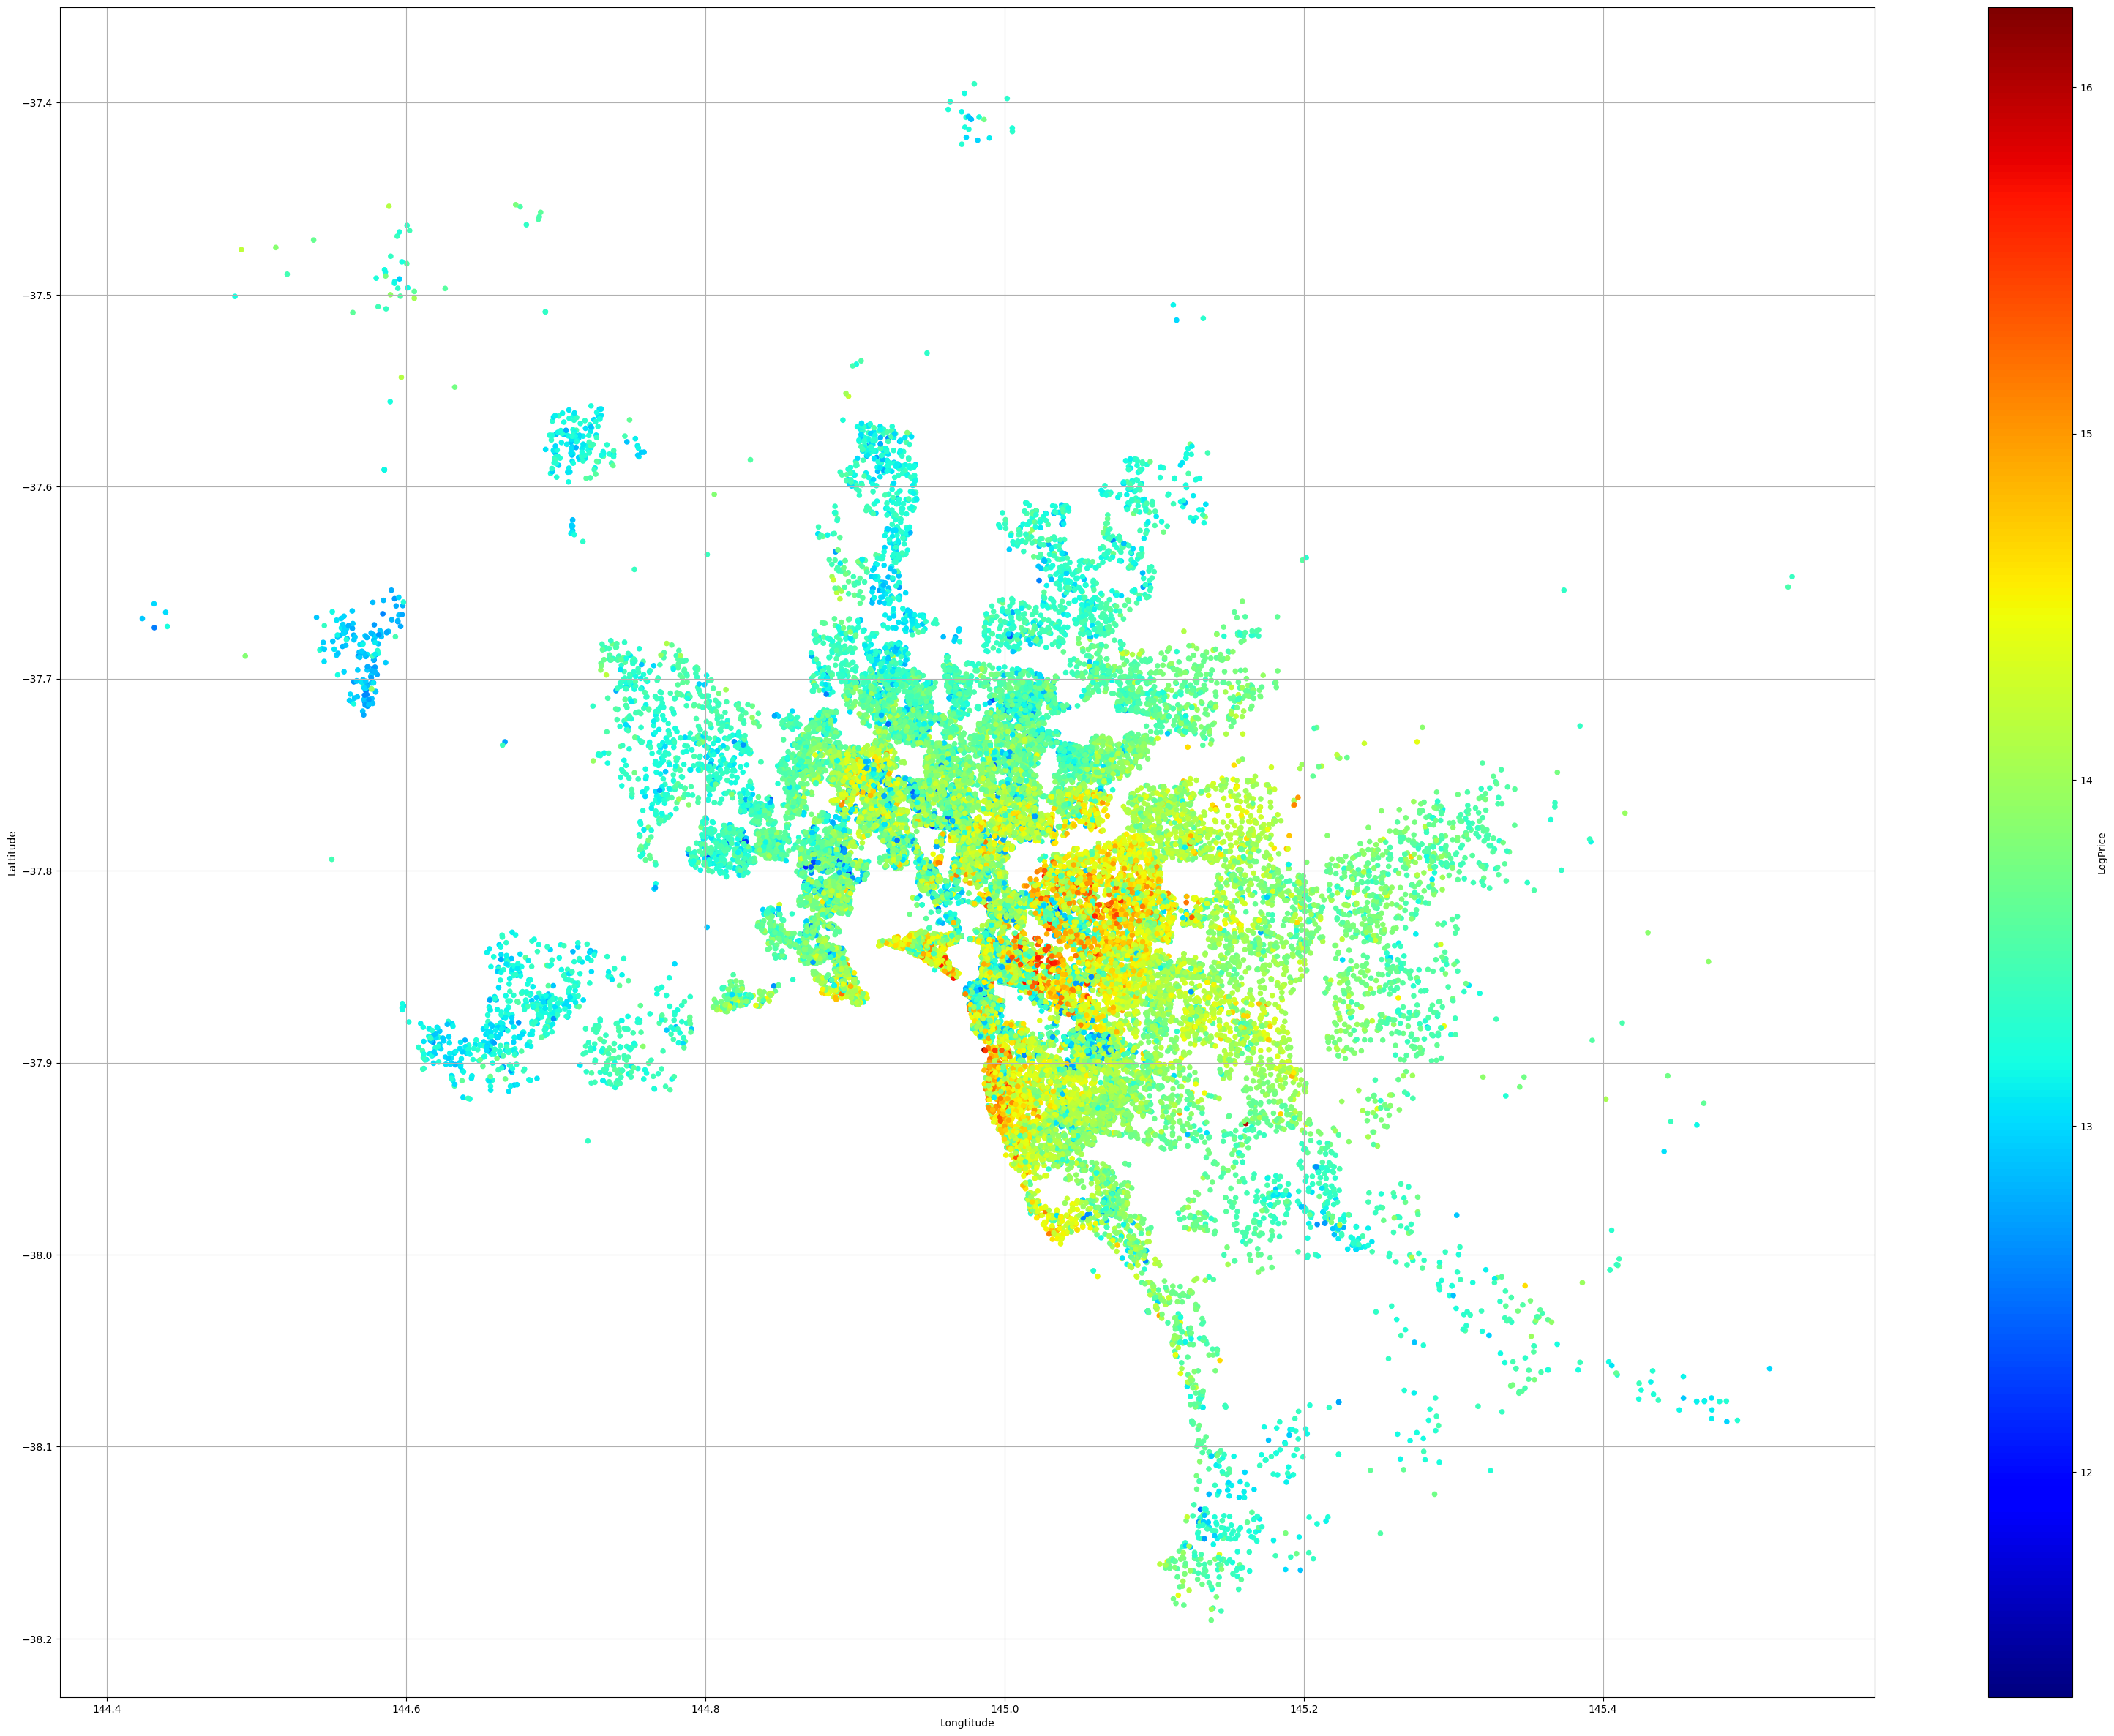

In [ ]:
housing.plot(kind="scatter", x="Longtitude", y="Lattitude", grid=True,
c="LogPrice", cmap="jet", colorbar=True,
legend=True, sharex=False, figsize=(40, 30))
plt.show()

Not only does this look much cooler, we can actually see that as houses stray further away from the CBD, they become more affordable. 

Some other things to note:
- The eastern suburbs tend to be more expensive, even at the CBD
- The eastern bayside areas are also quite expensive
- There are squarish "holes" in the scatterplot, these are most likely suburbs which have not been included in the data, or non residential areas.

In [ ]:
housing.columns

Index(['Suburb', 'Address', 'Rooms', 'Type', 'Price', 'Method', 'SellerG',
       'Date', 'Distance', 'Postcode', 'Bathroom', 'Car', 'Landsize',
       'BuildingArea', 'YearBuilt', 'CouncilArea', 'Lattitude', 'Longtitude',
       'Regionname', 'Propertycount', 'Month_Sold', 'Year_Sold', 'Day_Sold',
       'BuildingAge', 'LogPrice', 'LogPriceScaled'],
      dtype='object')

## **Building the Model**

#### **Creating the test set**

Before getting into it, it's important we set aside a test set so that we ensure that the models will be evaluated on unseen data, and that there is no data leakage. 

Instead of randomly picking out observations, we will try something called stratified sampling. This technique ensures that the test set is representative of the population, and prevents only one type of observation from being in the test set by chance.

In [ ]:
#we create a price category to create 5 strata of Price

housing["price_cat"] = pd.qcut(
    housing["Price"],
    q=5,
    labels=[1,2,3,4,5]
)

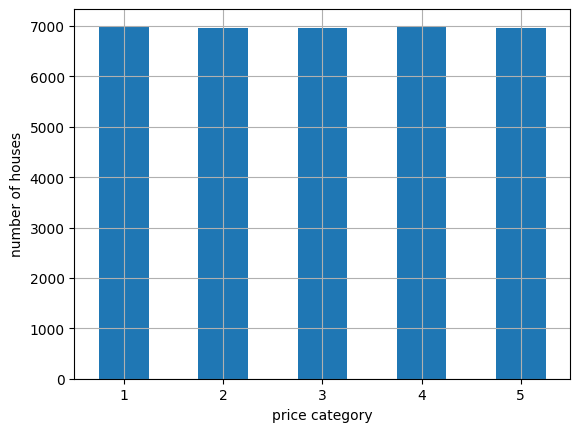

In [ ]:
housing["price_cat"].value_counts().sort_index().plot.bar(rot=0, grid = True)
plt.ylabel("number of houses")
plt.xlabel("price category")
plt.show()

In [ ]:
housing = housing.drop(columns=['LogPrice', 'LogPriceScaled'])

In [ ]:
splitter = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)
strat_splits = []
for train_index, test_index in splitter.split(housing, housing["price_cat"]):
    strat_train_set_n = housing.iloc[train_index]
    strat_test_set_n = housing.iloc[test_index]
    strat_splits.append([strat_train_set_n, strat_test_set_n])

In [ ]:
strat_train_set, strat_test_set = train_test_split(
housing, test_size=0.2, stratify=housing["price_cat"], random_state=42)

In [ ]:
strat_test_set["price_cat"].value_counts()/len(strat_test_set)

price_cat
4    0.200516
1    0.200373
2    0.199943
3    0.199656
5    0.199512
Name: count, dtype: float64

Now we have a stratified test set. We'll get rid of the "price_cat" column since we won't need it anymore.

In [ ]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop("price_cat", axis = 1, inplace=True)

In [ ]:
housingmodel = housing.drop(columns=["price_cat"])

### **Baseline Models**

We will now compare three different models: Linear regression, decision trees and random forest

In [ ]:
X_train = strat_train_set.drop(["Price"], axis=1)
y_train = strat_train_set["Price"]

In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Trees": DecisionTreeRegressor(),
    "Random Forests": RandomForestRegressor()
}

In [ ]:
results = []

In [ ]:
for name, model in models.items():
    print(f"Running: {name}")
    
    cv_results = cross_validate(
        model,
        X_train,
        y_train,
        cv=5,
        scoring={
            "rmse": "neg_root_mean_squared_error",
            "r2": "r2"
        },
        return_train_score=True
    )
    
    train_rmse = -cv_results["train_rmse"]
    val_rmse = -cv_results["test_rmse"]
    
    train_r2 = cv_results["train_r2"]
    val_r2 = cv_results["test_r2"]
    
    results.append({
        "Model": name,
        
        "Train RMSE Mean": train_rmse.mean(),
        "Train RMSE Std": train_rmse.std(),
        
        "Validation RMSE Mean": val_rmse.mean(),
        "Validation RMSE Std": val_rmse.std(),
        
        "Train R2 Mean": train_r2.mean(),
        "Train R2 Std": train_r2.std(),
        
        "Validation R2 Mean": val_r2.mean(),
        "Validation R2 Std": val_r2.std()
    })
    
    print(f"Train RMSE:      {train_rmse.mean():.2f} ± {train_rmse.std():.2f}")
    print(f"Validation RMSE: {val_rmse.mean():.2f} ± {val_rmse.std():.2f}")
    
    print(f"Train R2:        {train_r2.mean():.3f} ± {train_r2.std():.3f}")
    print(f"Validation R2:   {val_r2.mean():.3f} ± {val_r2.std():.3f}")
    
    print("-" * 40)

Running: Linear Regression
Train RMSE:      435131.13 ± 4120.74
Validation RMSE: 474745.93 ± 85562.34
Train R2:        0.561 ± 0.005
Validation R2:   0.465 ± 0.193
----------------------------------------
Running: Decision Trees
Train RMSE:      0.00 ± 0.00
Validation RMSE: 430754.26 ± 9265.23
Train R2:        1.000 ± 0.000
Validation R2:   0.570 ± 0.017
----------------------------------------
Running: Random Forests
Train RMSE:      114101.53 ± 1514.12
Validation RMSE: 304525.70 ± 13229.55
Train R2:        0.970 ± 0.001
Validation R2:   0.785 ± 0.016
----------------------------------------


In [ ]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by="Validation RMSE Mean")

results_df

,Model,Train RMSE Mean,Train RMSE Std,Validation RMSE Mean,Validation RMSE Std,Train R2 Mean,Train R2 Std,Validation R2 Mean,Validation R2 Std
2,Random Forests,114101.531305,1514.121924,304525.698603,13229.551667,0.969819,0.000686,0.784707,0.016468
1,Decision Trees,0.000000,0.000000,430754.256033,9265.230732,1.000000,0.000000,0.569557,0.017489
0,Linear Regression,435131.131957,4120.744043,474745.931290,85562.344533,0.561116,0.005286,0.465461,0.192657


It seems like random forest regression  is the clear winner!

Now, lets try to improve this.

### **Hyperparameter tuning**

We will go the RandomizedSearchCV route.

In [ ]:
param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

In [ ]:
randomf = RandomForestRegressor(random_state=42)

random_search = RandomizedSearchCV(
    randomf,
    param_dist,
    n_iter=20,
    scoring="neg_root_mean_squared_error",
    cv = 5,
    verbose = 2,
    random_state = 42,
    n_jobs = -1

)

In [ ]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,RandomForestR...ndom_state=42)
,param_distributions,"{'max_depth': [10, 20, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,n_iter,20
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [ ]:
best_randomf = random_search.best_estimator_

print(random_search.best_params_)
print(-random_search.best_score_)

{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}
301513.8860085701


Now we have the best version of the random forest model

### **Feature Importance**

In [ ]:
best_randomf.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
importances = best_randomf.feature_importances_

In [ ]:
feature_names = X_train.columns

In [ ]:
important_df = pd.DataFrame({"Feature":feature_names, "Importance":importances})

In [ ]:
important_df = important_df.sort_values(
    by="Importance",
    ascending=False
)
print(important_df.head(15))

          Feature  Importance
2           Rooms    0.117450
7        Distance    0.093848
12   BuildingArea    0.086464
8        Postcode    0.075918
15      Lattitude    0.075887
9        Bathroom    0.071019
16     Longtitude    0.068514
14    CouncilArea    0.051658
3            Type    0.049688
22    BuildingAge    0.045972
13      YearBuilt    0.043833
11       Landsize    0.040002
17     Regionname    0.034349
18  Propertycount    0.023891
0          Suburb    0.023025
